# Michigan County Nurse Supply Heatmaps

Choropleths of the most recent county-level snapshots of nurse supply across Michigan's 83 counties.

**Four heatmaps:**
1. RN licensed per 100,000 residents (2023)
2. LPN licensed per 100,000 residents (2023)
3. RN licensed per 1,000 residents aged 65+ (2023) — geriatric-need scaled
4. LPN licensed per 1,000 residents aged 65+ (2023) — geriatric-need scaled

Per-65+ scaling captures the fact that nursing labor demand is concentrated in elderly care. A county with high per-capita RN density but a young population may still be under-supplied for geriatric need; per-65+ scaling normalizes for this.

Data sources: county licensure counts (`michigan_nurse_county_panel.csv` → `rn_per_100k`, `lpn_per_100k`, `rn_licensed_county`, `lpn_licensed_county`); ACS population (`pop_total`, `pop_65plus`).

In [1]:
# Install (once) — restart kernel after the first run
%pip install -q geopandas SciencePlots requests

Note: you may need to restart the kernel to use updated packages.


In [2]:
import io
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import requests
import scienceplots  # noqa: F401

plt.style.use(['science', 'no-latex', 'grid'])
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white', 'font.size': 10,
    'text.color': '#000000', 'axes.labelcolor': '#000000',
    'axes.edgecolor': '#000000',
    'xtick.color': '#000000', 'ytick.color': '#000000',
})

ROOT = Path('..')
panel = pd.read_csv(ROOT / 'data' / 'analytic' / 'michigan_nurse_county_panel.csv', low_memory=False,
                     dtype={'fips': str})
panel['fips'] = panel['fips'].str.zfill(5)
print('panel:', panel.shape)

panel: (1162, 157)


In [3]:
# County geometry — Census TIGER cb_2022_us_county_20m, cached locally
SHP_DIR = ROOT / 'data' / 'shp'
SHP_DIR.mkdir(parents=True, exist_ok=True)
shp_path = SHP_DIR / 'cb_2022_us_county_20m.shp'
if not shp_path.exists():
    url = ('https://www2.census.gov/geo/tiger/GENZ2022/shp/'
            'cb_2022_us_county_20m.zip')
    r = requests.get(url, timeout=60); r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(SHP_DIR)
counties = gpd.read_file(shp_path)
mi = counties[counties['STATEFP'] == '26'].copy()
mi['fips'] = mi['STATEFP'] + mi['COUNTYFP']
mi = mi.to_crs(epsg=3078)  # Michigan GeoRef
print('mi geom:', mi.shape)

mi geom: (83, 14)


In [4]:
# Derive per-65+ rates. Use AHRF-loaded pop_65plus where present; fall back
# to ACS-derived pop_total*pct_65plus/100 otherwise.
snap_year = 2023
snap = panel[panel['year'] == snap_year].copy()
snap['pop_65plus_used'] = snap['pop_65plus']
if snap['pop_65plus_used'].isna().any():
    fb = snap['pop_total'] * snap['pct_65plus'] / 100
    snap['pop_65plus_used'] = snap['pop_65plus_used'].fillna(fb)

# RN/LPN per 1,000 aged 65+ — geriatric-need scaling
snap['rn_per_1k_65plus']  = snap['rn_licensed_county']  / snap['pop_65plus_used'] * 1000
snap['lpn_per_1k_65plus'] = snap['lpn_licensed_county'] / snap['pop_65plus_used'] * 1000

print(f'{snap_year} distributions:')
print(snap[['rn_per_100k', 'lpn_per_100k',
             'rn_per_1k_65plus', 'lpn_per_1k_65plus']].describe().round(1))

2023 distributions:
       rn_per_100k  lpn_per_100k  rn_per_1k_65plus  lpn_per_1k_65plus
count         83.0          83.0              83.0               83.0
mean        1311.3         221.4              60.7                9.9
std          314.5         105.9              20.1                4.6
min          564.8          70.3              21.3                2.7
25%         1096.8         146.7              45.0                6.6
50%         1251.7         198.5              58.1                9.2
75%         1522.2         267.8              72.7               12.3
max         2160.0         612.7             114.8               30.6


In [5]:
# Shared MSA central-county lookup (matches style of Heatmaps.ipynb)
CBSA_CENTRAL_FIPS = {
    'Adrian, MI Micro SA': '26091', 'Alma, MI Micro SA': '26057',
    'Alpena, MI Micro SA': '26007', 'Ann Arbor, MI Metro SA': '26161',
    'Battle Creek, MI Metro SA': '26025', 'Bay City, MI Metro SA': '26017',
    'Big Rapids, MI Micro SA': '26107', 'Cadillac, MI Micro SA': '26165',
    'Coldwater, MI Micro SA': '26023',
    'Detroit-Warren-Dearborn, MI Metro SA': '26163',
    'Escanaba, MI Micro SA': '26041', 'Flint, MI Metro SA': '26049',
    'Grand Rapids-Wyoming-Kentwood, MI Metro SA': '26081',
    'Hillsdale, MI Micro SA': '26059', 'Holland, MI Micro SA': '26005',
    'Houghton, MI Micro SA': '26061', 'Iron Mountain, MI-WI Micro SA': '26043',
    'Jackson, MI Metro SA': '26075', 'Kalamazoo-Portage, MI Metro SA': '26077',
    'Lansing-East Lansing, MI Metro SA': '26065',
    'Ludington, MI Micro SA': '26105', 'Marquette, MI Micro SA': '26103',
    'Midland, MI Metro SA': '26111', 'Monroe, MI Metro SA': '26115',
    'Mount Pleasant, MI Micro SA': '26073',
    'Muskegon-Norton Shores, MI Metro SA': '26121',
    'Niles, MI Metro SA': '26021', 'Owosso, MI Micro SA': '26155',
    'Petoskey, MI Micro SA': '26047', 'Saginaw, MI Metro SA': '26145',
    'Sault Ste. Marie, MI Micro SA': '26033', 'Sturgis, MI Micro SA': '26149',
    'Traverse City, MI Metro SA': '26055',
}
metro_cbsa_names = set(
    snap.loc[snap['cbsa_ind'].astype(str).str.contains('Metro|1', case=False, na=False),
              'cbsa_name'].dropna().unique())
msa_central_fips = {f for n, f in CBSA_CENTRAL_FIPS.items() if n in metro_cbsa_names}

FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

PALETTE = ['#eff3ff', '#bdd7e7', '#6baed6', '#3182bd', '#08519c']


In [6]:
def make_heatmap(snap_df, mi_geom, var, title, palette,
                  legend_title, fmt='{:.0f}', source='MI Nurse Map / ACS',
                  out_png=None, show_stars=True, legend_loc='lower left',
                  legend_bbox=None, legend_fontsize=9, legend_title_fontsize=10,
                  draw_legend=True, edge_fmt='{:.0f}'):
    cols = ['fips', 'county_name', var]
    pop_col = 'pop_65plus_used' if '65plus' in var else 'pop_total'
    if pop_col in snap_df.columns:
        cols.append(pop_col)
    gdf = mi_geom.merge(snap_df[cols], on='fips', how='left').copy()

    valid = gdf[var].notna()
    gdf.loc[valid, 'qbin'], q_edges = pd.qcut(
        gdf.loc[valid, var], q=5, labels=False, retbins=True, duplicates='drop')
    q_edges = np.round(q_edges, 1)

    fig, ax = plt.subplots(figsize=(12, 13))
    gdf.plot(column='qbin', cmap=ListedColormap(palette),
             linewidth=0.5, edgecolor='#333333', categorical=True, legend=False,
             missing_kwds={'color': '#e8e8e8', 'edgecolor': '#333333',
                           'hatch': '////', 'label': 'No data'}, ax=ax)

    name_style = dict(ha='center', va='center', fontsize=6.0, color='#000000',
                       fontweight='bold',
                       path_effects=[pe.withStroke(linewidth=2.5,
                                                    foreground='white')])
    hl_style = dict(ha='center', va='center', fontsize=9.0, color='#000000',
                     fontweight='bold',
                     path_effects=[pe.withStroke(linewidth=3.5,
                                                  foreground='white')])
    ranked = gdf.dropna(subset=[var]).sort_values(var)
    significant = set(pd.concat([ranked.head(5), ranked.tail(5)])['fips'])

    for _, row in gdf.iterrows():
        if pd.isna(row.geometry): continue
        pt = row.geometry.representative_point()
        name = (row['county_name'] if isinstance(row['county_name'], str)
                 else row['NAME'])
        is_msa = row['fips'] in msa_central_fips
        offset = (0, 14) if (is_msa and show_stars) else (0, 0)
        if row['fips'] in significant and pd.notna(row[var]):
            label = f"{name}\n{fmt.format(row[var])}"
            ax.annotate(label, xy=(pt.x, pt.y), xytext=offset,
                        textcoords='offset points', **hl_style)
        else:
            ax.annotate(name, xy=(pt.x, pt.y), xytext=offset,
                        textcoords='offset points', **name_style)
        if is_msa and show_stars:
            ax.scatter([pt.x], [pt.y], marker='*', s=180, color='#c62828',
                       edgecolor='black', linewidth=0.6, zorder=6)

    patches = [Patch(facecolor=palette[i], edgecolor='#333333',
                      label=f"Q{i+1}: {edge_fmt.format(q_edges[i])} – {edge_fmt.format(q_edges[i+1])}")
                for i in range(len(palette))]
    patches.append(Patch(facecolor='#e8e8e8', edgecolor='#333333',
                          hatch='////', label='No data'))
    if draw_legend:
        ax.legend(handles=patches, title=legend_title, loc=legend_loc,
                  bbox_to_anchor=legend_bbox, frameon=True,
                  fontsize=legend_fontsize, title_fontsize=legend_title_fontsize)

    ax.set_title(title, fontsize=20, fontweight='bold', pad=14)
    ax.set_axis_off()
    plt.tight_layout()
    if out_png:
        plt.savefig(out_png, dpi=200, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
    plt.show()
    return gdf

In [7]:
def save_legend(snap_df, mi_geom, var, legend_title, palette, out_png,
                fontsize=16, title_fontsize=18, dpi=200, edge_fmt='{:.0f}',
                ncol=1, figsize=(4, 3)):
    """Render only the quintile legend for `var` as a standalone, tightly
    cropped PNG so it can be sized independently (e.g. in LaTeX/Overleaf)."""
    gdf = mi_geom.merge(snap_df[['fips', var]], on='fips', how='left')
    valid = gdf[var].notna()
    _, q_edges = pd.qcut(gdf.loc[valid, var], q=5, labels=False,
                          retbins=True, duplicates='drop')
    q_edges = np.round(q_edges, 1)
    patches = [Patch(facecolor=palette[i], edgecolor='#333333',
                      label=f"Q{i+1}: {edge_fmt.format(q_edges[i])} – {edge_fmt.format(q_edges[i+1])}")
                for i in range(len(palette))]
    patches.append(Patch(facecolor='#e8e8e8', edgecolor='#333333',
                          hatch='////', label='No data'))
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    leg = ax.legend(handles=patches, title=legend_title, loc='center',
                    ncol=ncol, frameon=True, fontsize=fontsize,
                    title_fontsize=title_fontsize)
    fig.canvas.draw()
    bbox = leg.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(out_png, dpi=dpi, bbox_inches=bbox, facecolor='white')
    plt.show()
    print('saved', out_png)


def save_combined_legend(snap_df, mi_geom, rn_var, lpn_var, palette, out_png,
                         unit_label, fontsize=15, title_fontsize=17, dpi=200):
    """One HORIZONTAL legend covering the RN and LPN maps that share a slide.
    Each map is quintiled independently, so every swatch is annotated with both
    the RN and LPN value range. Tightly cropped for Overleaf (place at bottom)."""
    def edges(var):
        g = mi_geom.merge(snap_df[['fips', var]], on='fips', how='left')
        v = g[var].notna()
        _, e = pd.qcut(g.loc[v, var], q=5, labels=False, retbins=True,
                        duplicates='drop')
        return np.round(e, 1)
    rn_e, lpn_e = edges(rn_var), edges(lpn_var)
    patches = [Patch(facecolor=palette[i], edgecolor='#333333',
                      label=(f'Q{i+1}\n'
                             f'RN {rn_e[i]:.0f}\u2013{rn_e[i+1]:.0f}\n'
                             f'LPN {lpn_e[i]:.0f}\u2013{lpn_e[i+1]:.0f}'))
                for i in range(len(palette))]
    patches.append(Patch(facecolor='#e8e8e8', edgecolor='#333333',
                          hatch='////', label='No data'))
    fig, ax = plt.subplots(figsize=(13, 2.2))
    ax.set_axis_off()
    leg = ax.legend(handles=patches, title=f'Quintile bins \u2014 {unit_label}',
                    loc='center', ncol=len(patches), frameon=True,
                    fontsize=fontsize, title_fontsize=title_fontsize,
                    handlelength=1.4, handleheight=1.4,
                    columnspacing=1.6, borderpad=0.8)
    fig.canvas.draw()
    bbox = leg.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(out_png, dpi=dpi, bbox_inches=bbox, facecolor='white')
    plt.show()
    print('saved', out_png)


## Heatmap 1 — RN per 100,000 residents (2023)

**What's visualized:** licensed RNs per 100,000 residents per county, the standard per-capita workforce density measure.

**Interpretation guide:** higher values (darker blue) are typically expected in counties with major hospital systems and academic medical centers. Counties with no/low values may reflect either genuine workforce scarcity or commuting patterns — many nurses live outside the county where they work.

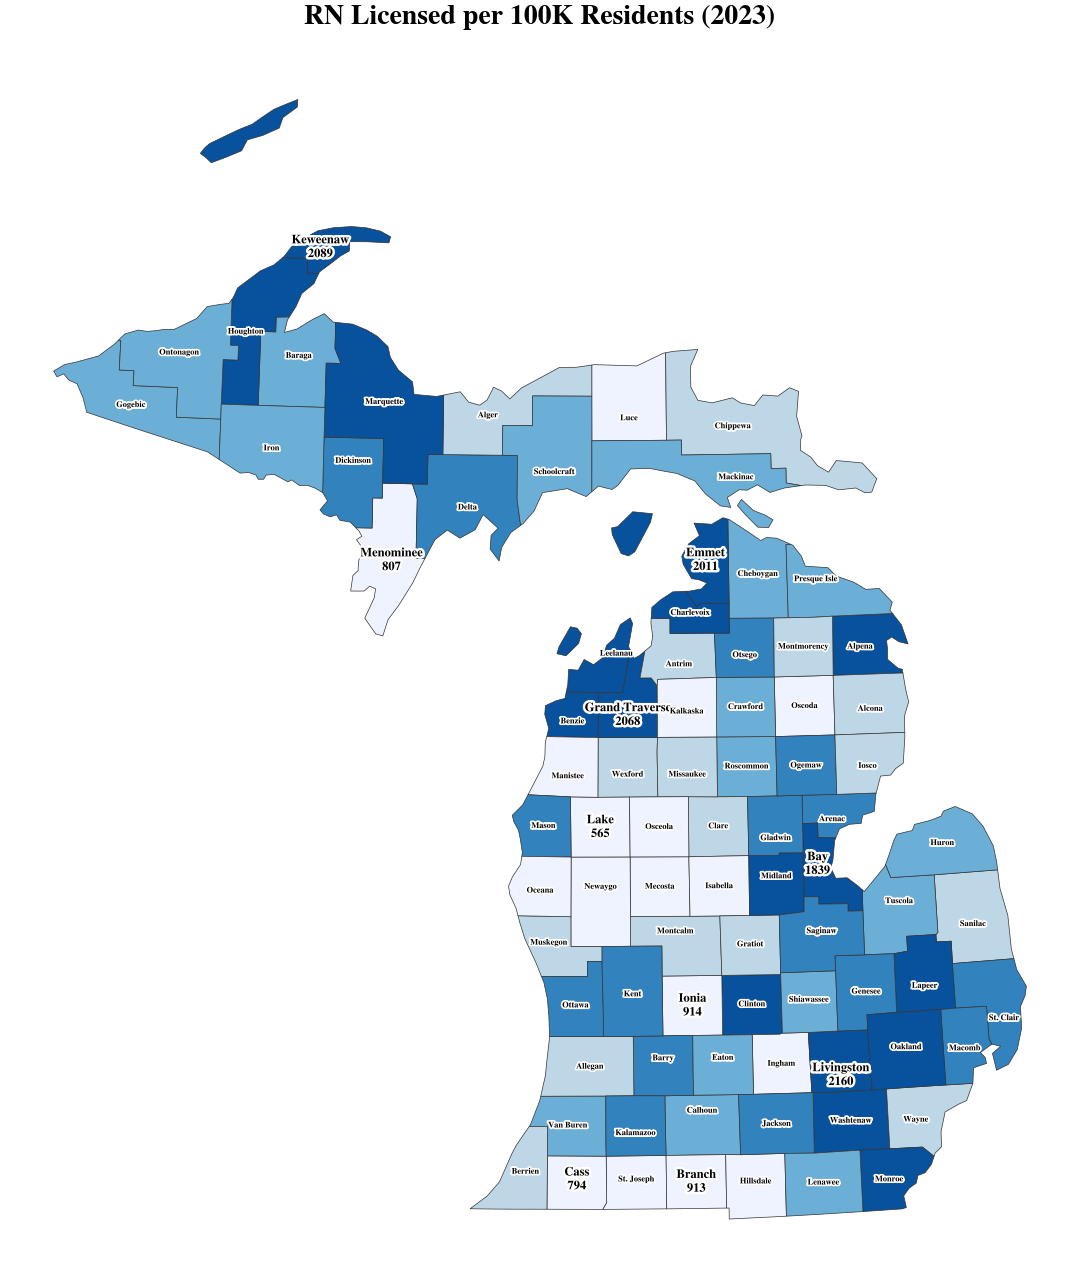

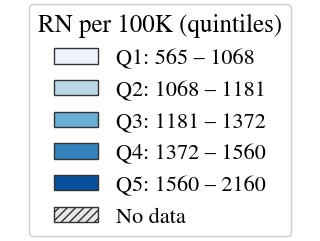

saved ../figures/legend_rn_per_100k_2023.png


In [8]:
make_heatmap(snap, mi, 'rn_per_100k',
              title=f'RN Licensed per 100K Residents ({snap_year})',
              palette=PALETTE,
              legend_title='RN per 100K (quintiles)',
              fmt='{:.0f}',
              source='MI Nurse Licensure (BPL) / ACS',
              show_stars=False, draw_legend=False,
              out_png=FIG_DIR / f'heatmap_rn_per_100k_{snap_year}.png')
save_legend(snap, mi, 'rn_per_100k', 'RN per 100K (quintiles)', PALETTE,
            out_png=FIG_DIR / f'legend_rn_per_100k_{snap_year}.png')

## Heatmap 2 — LPN per 100,000 residents (2023)

**What's visualized:** licensed LPNs per 100,000 residents per county.

**Interpretation guide:** LPN supply is more dispersed than RN supply geographically because LPNs work disproportionately in nursing homes and outpatient long-term care, which are spread more evenly across rural and urban counties than acute-care hospitals are.

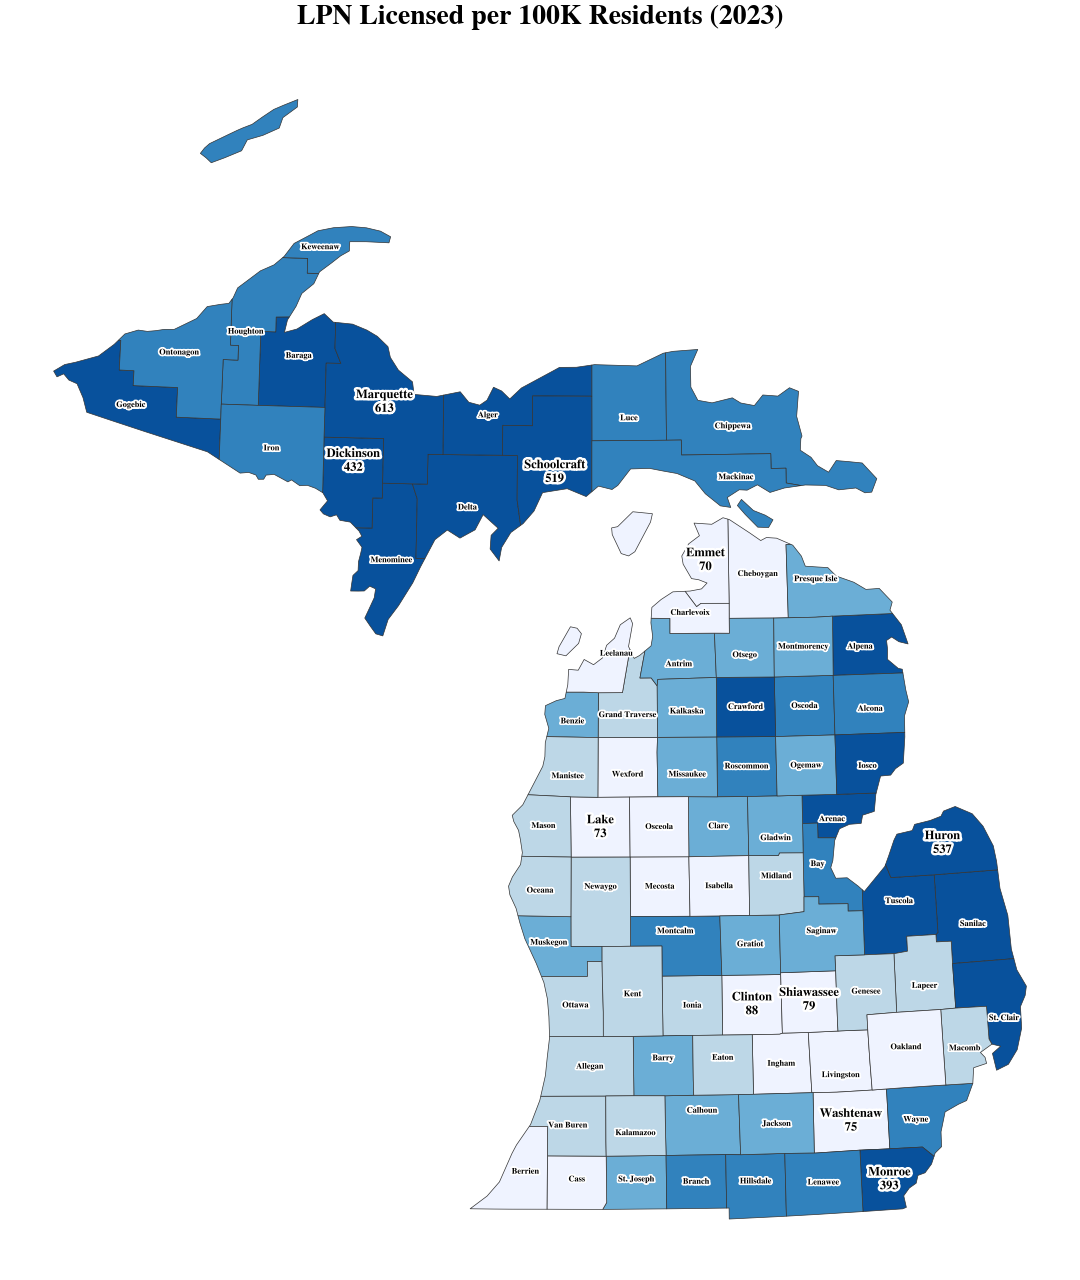

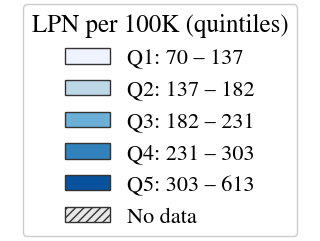

saved ../figures/legend_lpn_per_100k_2023.png


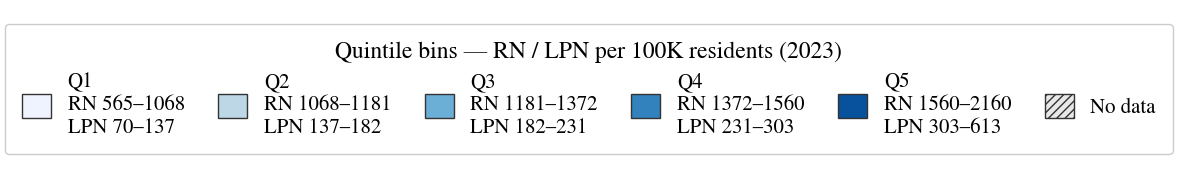

saved ../figures/legend_combined_per_100k_2023.png


In [9]:
make_heatmap(snap, mi, 'lpn_per_100k',
              title=f'LPN Licensed per 100K Residents ({snap_year})',
              palette=PALETTE,
              legend_title='LPN per 100K (quintiles)',
              fmt='{:.0f}',
              source='MI Nurse Licensure (BPL) / ACS',
              show_stars=False, draw_legend=False,
              out_png=FIG_DIR / f'heatmap_lpn_per_100k_{snap_year}.png')
save_legend(snap, mi, 'lpn_per_100k', 'LPN per 100K (quintiles)', PALETTE,
            out_png=FIG_DIR / f'legend_lpn_per_100k_{snap_year}.png')
save_combined_legend(snap, mi, 'rn_per_100k', 'lpn_per_100k', PALETTE,
                     out_png=FIG_DIR / f'legend_combined_per_100k_{snap_year}.png',
                     unit_label='RN / LPN per 100K residents (2023)')


## Heatmap 3 — RN per 1,000 residents aged 65+ (2023)

**What's visualized:** licensed RNs per 1,000 residents aged 65 and over.

**Why this scaling matters:** raw per-100K rates conflate two distinct supply questions — workforce availability per resident *generally*, versus workforce availability per *unit of geriatric need*. The 65+ denominator isolates the latter. A county with high RN density relative to total population but a large elderly share can still appear under-supplied here, while a young county with moderate RN density may look well-supplied per 65+ resident.

**Compare to Heatmap 1**: counties that drop one or two quintiles between the two maps are those facing disproportionate elder-care load relative to general population.

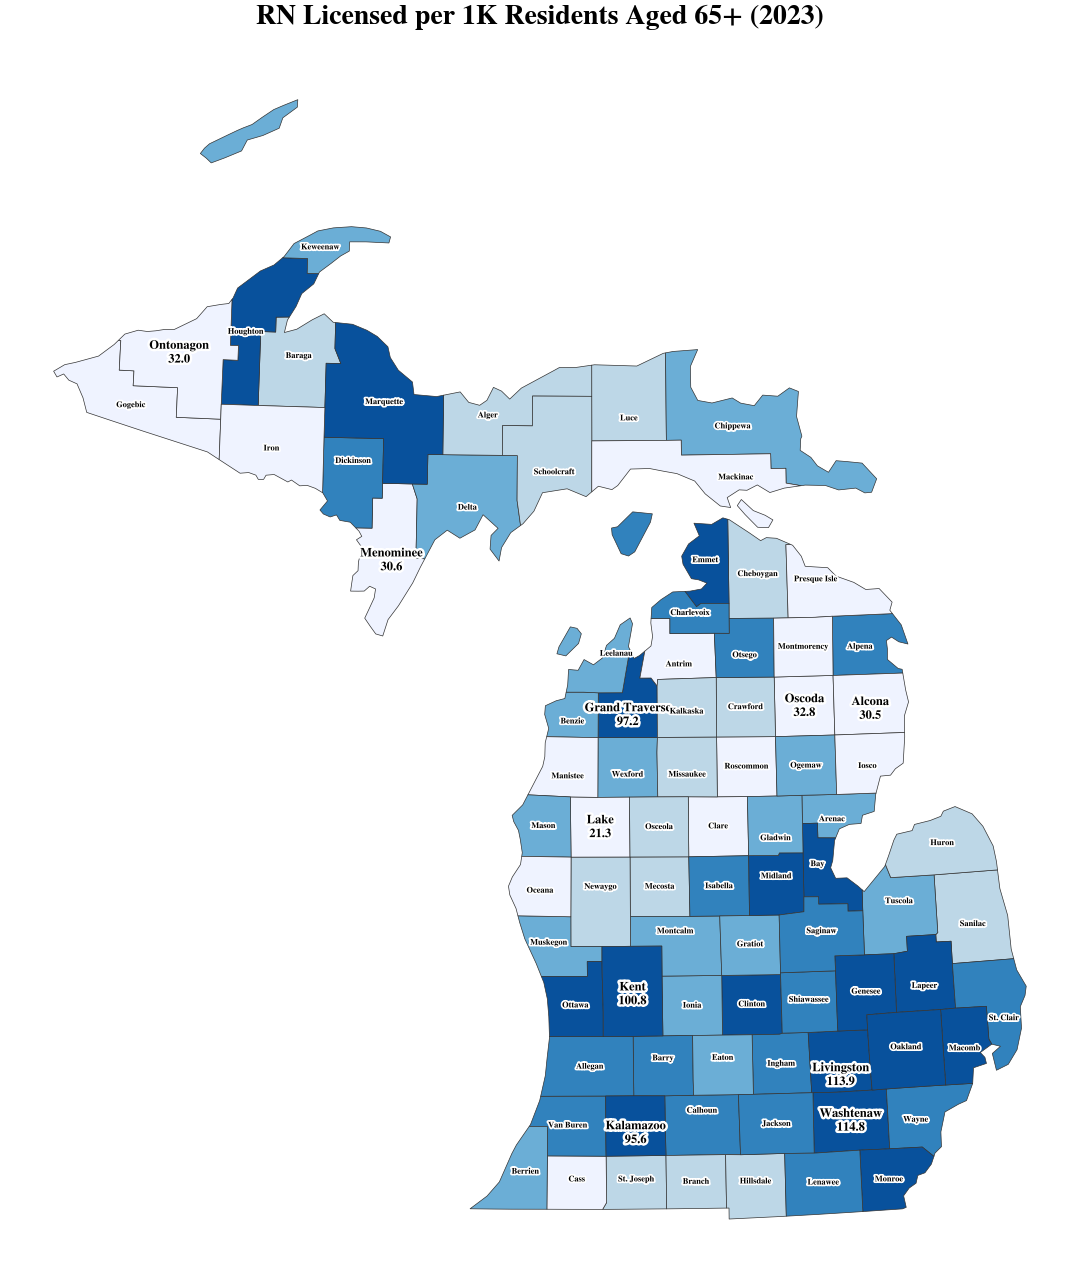

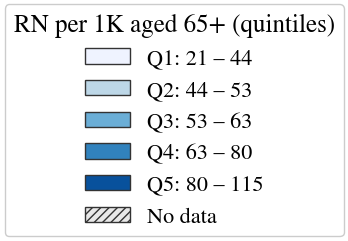

saved ../figures/legend_rn_per_1k_65plus_2023.png


In [10]:
make_heatmap(snap, mi, 'rn_per_1k_65plus',
              title=f'RN Licensed per 1K Residents Aged 65+ ({snap_year})',
              palette=PALETTE,
              legend_title='RN per 1K aged 65+ (quintiles)',
              fmt='{:.1f}',
              source='MI Nurse Licensure (BPL) / ACS pop 65+',
              show_stars=False, draw_legend=False,
              out_png=FIG_DIR / f'heatmap_rn_per_1k_65plus_{snap_year}.png')
save_legend(snap, mi, 'rn_per_1k_65plus', 'RN per 1K aged 65+ (quintiles)', PALETTE,
            out_png=FIG_DIR / f'legend_rn_per_1k_65plus_{snap_year}.png')

## Heatmap 4 — LPN per 1,000 residents aged 65+ (2023)

**What's visualized:** licensed LPNs per 1,000 residents aged 65 and over.

**Why this scaling matters for LPNs especially:** LPNs are the workforce most concentrated in long-term-care settings (~40% of all LPN employment nationally is in nursing homes), so the per-65+ denominator more directly reflects the labor pool relative to the population segment that drives LPN demand.

**Compare to Heatmap 2**: where the per-100K and per-65+ maps diverge most for LPNs is where the writeup's structural-mismatch hypothesis is most testable — those are the counties carrying disproportionate geriatric load with limited LPN supply.

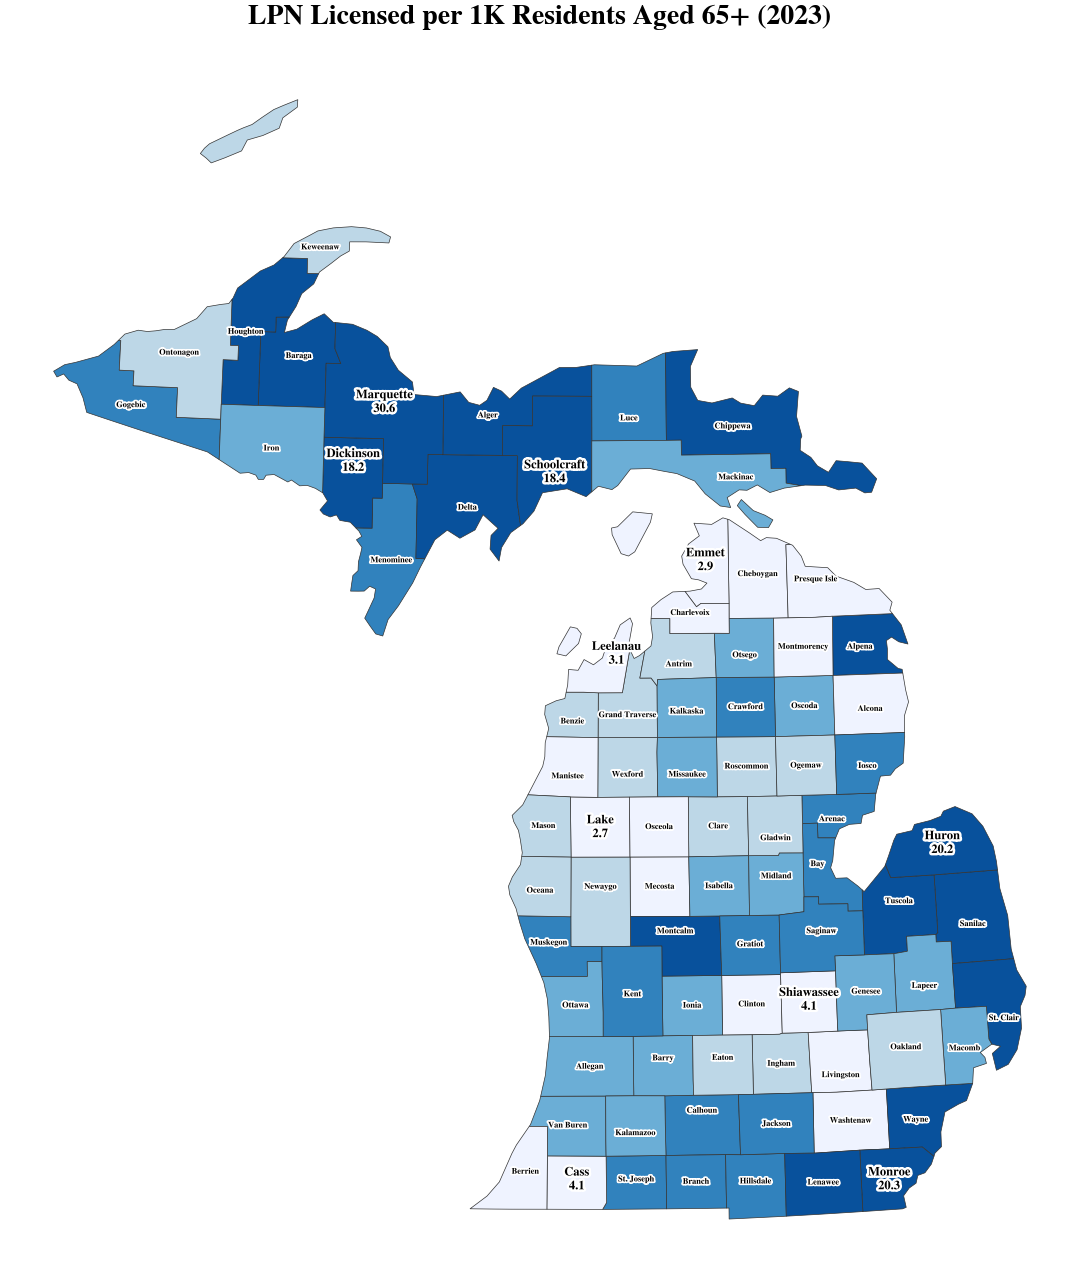

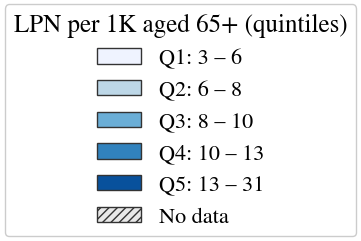

saved ../figures/legend_lpn_per_1k_65plus_2023.png


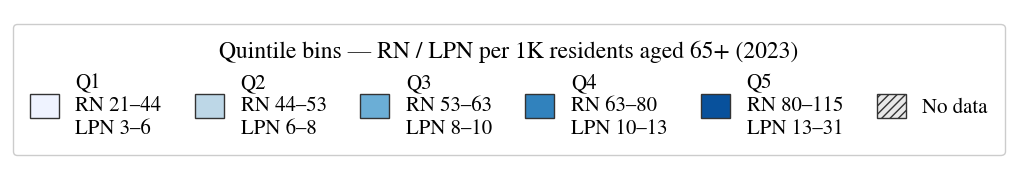

saved ../figures/legend_combined_per_1k_65plus_2023.png


In [11]:
make_heatmap(snap, mi, 'lpn_per_1k_65plus',
              title=f'LPN Licensed per 1K Residents Aged 65+ ({snap_year})',
              palette=PALETTE,
              legend_title='LPN per 1K aged 65+ (quintiles)',
              fmt='{:.1f}',
              source='MI Nurse Licensure (BPL) / ACS pop 65+',
              show_stars=False, draw_legend=False,
              out_png=FIG_DIR / f'heatmap_lpn_per_1k_65plus_{snap_year}.png')
save_legend(snap, mi, 'lpn_per_1k_65plus', 'LPN per 1K aged 65+ (quintiles)', PALETTE,
            out_png=FIG_DIR / f'legend_lpn_per_1k_65plus_{snap_year}.png')
save_combined_legend(snap, mi, 'rn_per_1k_65plus', 'lpn_per_1k_65plus', PALETTE,
                     out_png=FIG_DIR / f'legend_combined_per_1k_65plus_{snap_year}.png',
                     unit_label='RN / LPN per 1K residents aged 65+ (2023)')


## Reading the four maps together

1. **Heatmap 1 vs 2 (RN vs LPN per 100K)**: identifies which counties are *RN-heavy* (often metropolitan hospital hubs) vs *LPN-heavy* (often non-metro counties with concentrated LTC capacity).
2. **Heatmap 1 vs 3 (RN per 100K vs per 65+)**: counties that drop quintiles between the two are aging counties where general per-capita RN supply *understates* the supply pressure relative to geriatric need.
3. **Heatmap 2 vs 4 (LPN per 100K vs per 65+)**: the same comparison for LPNs. Because LPNs are more LTC-concentrated than RNs, the per-65+ denominator is closer to the structurally relevant 'need' measure for this workforce.
4. **Counties that rank low across all four maps** are the structural-mismatch candidates: under-supplied on both occupations and on both per-capita and per-65+ scaling. These are the policy-priority counties under the framework.

Figures saved to `../figures/`.

## Heatmap 5 — Percent of population aged 65+ (2023)

**What's visualized:** the share of each county's population aged 65 and over — the geriatric-need denominator behind the per-65+ scaling in Heatmaps 3 & 4, mapped directly.

**Interpretation guide:** the darkest counties (Upper Peninsula and the northern Lower Peninsula tip) carry the heaviest elderly load. Read this alongside Heatmaps 3 & 4 — a county that is both dark here and light there is the structural-mismatch case: high geriatric need, thin nurse supply per 65+ resident.

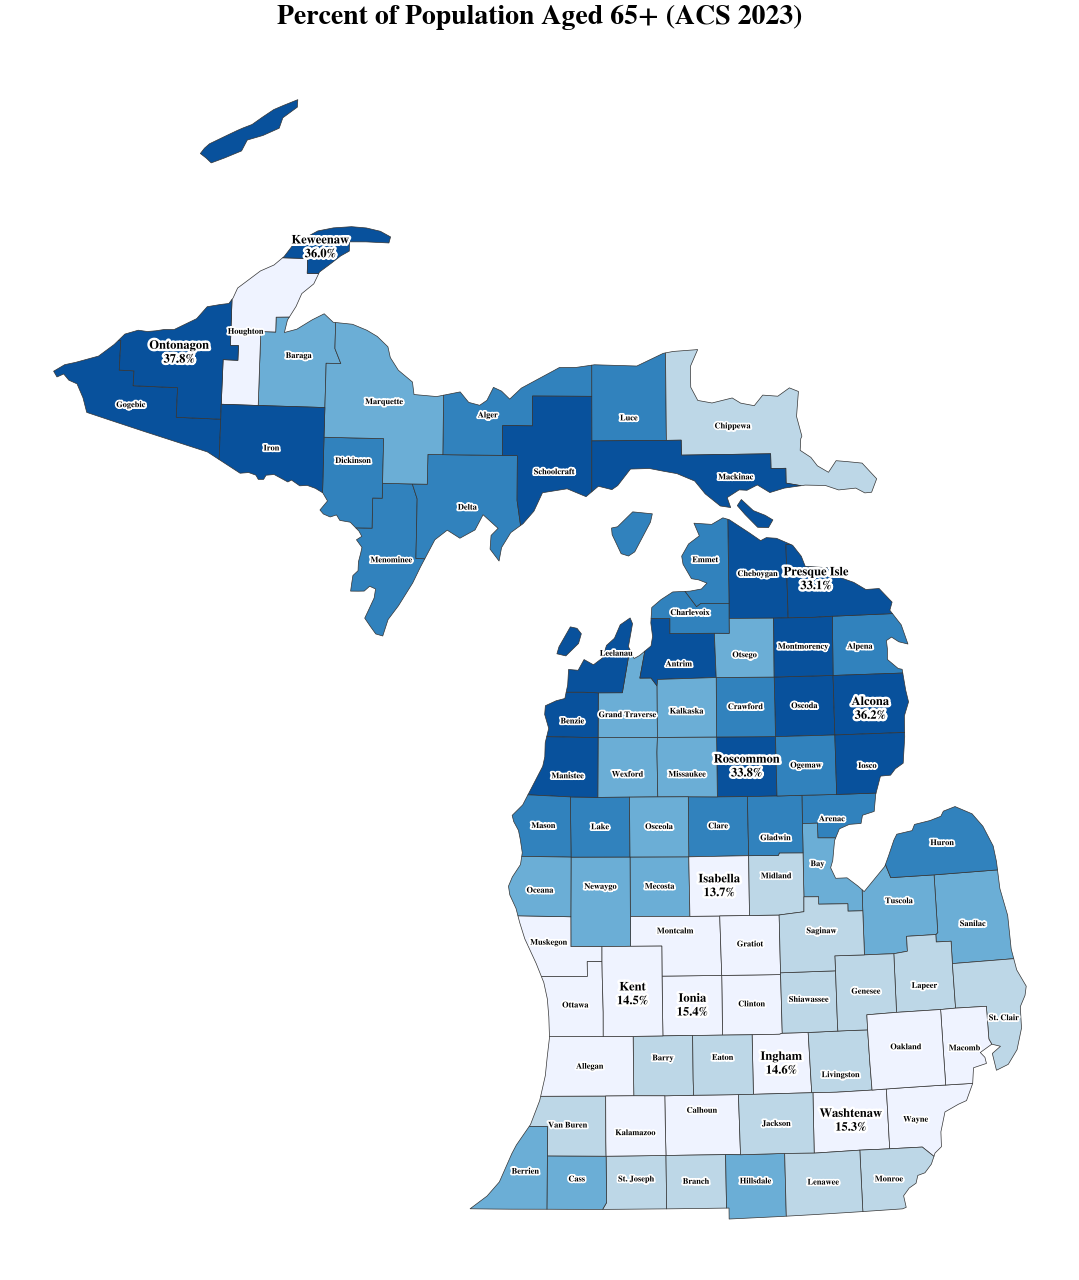

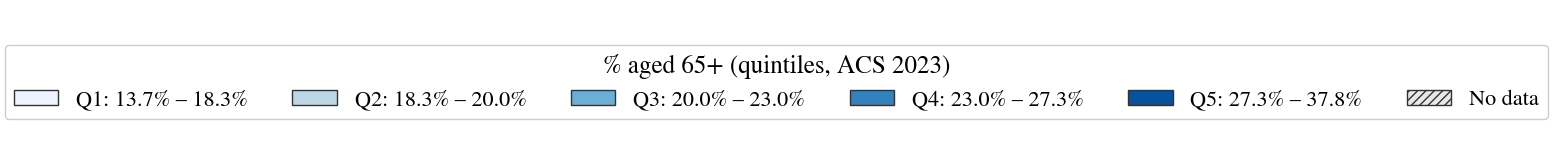

saved ../figures/legend_pct_65plus_2023.png


In [12]:
# Percent of population aged 65+ — geriatric-need share itself
snap['pct_65plus_used'] = snap['pop_65plus_used'] / snap['pop_total'] * 100

make_heatmap(snap, mi, 'pct_65plus_used',
              title=f'Percent of Population Aged 65+ (ACS {snap_year})',
              palette=PALETTE,
              legend_title=f'% aged 65+ (quintiles, ACS {snap_year})',
              fmt='{:.1f}%',
              source='U.S. Census Bureau ACS 5-Year, Table B01001',
              show_stars=False, draw_legend=False, edge_fmt='{:.1f}%',
              out_png=FIG_DIR / f'heatmap_pct_65plus_{snap_year}.png')
save_legend(snap, mi, 'pct_65plus_used',
            f'% aged 65+ (quintiles, ACS {snap_year})', PALETTE,
            out_png=FIG_DIR / f'legend_pct_65plus_{snap_year}.png',
            edge_fmt='{:.1f}%', ncol=6, figsize=(13, 2))

---
# 75+ (oldest-old) companion maps

The same geriatric-need scaling as Heatmaps 3–5, but using the population aged **75+** instead of 65+. The 75+ band is the more direct driver of long-term-care and nursing-home demand, so RN/LPN supply per 1,000 residents aged 75+ is a tighter “supply per unit of intensive elder-care need” measure.

`michigan_nurse_county_panel.csv` carries no 75+ population, so it is derived from `share_75plus` (% of total population aged 75+, ACS Table B01001) in the v2 regression panel: `pop_75plus = share_75plus / 100 × pop_total`. Figures are written alongside the 65+ maps in `../figures/` with a `_75plus_` tag (the 65+ maps are left in place).

In [13]:
# ── Derive 75+ population + geriatric-need rates (companion to the 65+ block above) ──
# michigan_nurse_county_panel.csv has no 75+ population; bring in share_75plus from the v2 panel
# and form pop_75plus = share_75plus/100 * pop_total, mirroring the 65+ fallback logic.
_v2 = pd.read_csv(ROOT / 'data' / 'analytic' / 'michigan_nurse_county_panel.csv',
                  low_memory=False, dtype={'fips': str})
_v2['fips'] = _v2['fips'].str.zfill(5)
_sev75 = _v2.loc[_v2['year'] == snap_year, ['fips', 'share_75plus']].copy()

# idempotent: drop any 75+ columns from a previous run before re-merging
snap = snap.drop(columns=[c for c in ['share_75plus', 'pop_75plus_used',
        'rn_per_1k_75plus', 'lpn_per_1k_75plus', 'pct_75plus_used'] if c in snap.columns])
snap = snap.merge(_sev75, on='fips', how='left')

snap['pop_75plus_used'] = snap['pop_total'] * snap['share_75plus'] / 100
snap['rn_per_1k_75plus']  = snap['rn_licensed_county']  / snap['pop_75plus_used'] * 1000
snap['lpn_per_1k_75plus'] = snap['lpn_licensed_county'] / snap['pop_75plus_used'] * 1000
snap['pct_75plus_used']   = snap['pop_75plus_used'] / snap['pop_total'] * 100

print(f'{snap_year} 75+ coverage: share_75plus non-null = '
      f'{snap["share_75plus"].notna().sum()} / {len(snap)}')
print(snap[['rn_per_1k_75plus', 'lpn_per_1k_75plus', 'pct_75plus_used']].describe().round(2))

2023 75+ coverage: share_75plus non-null = 83 / 83
       rn_per_1k_75plus  lpn_per_1k_75plus  pct_75plus_used
count             83.00              83.00            83.00
mean             154.66              25.28             8.96
std               51.22              11.79             2.25
min               59.98               7.57             5.16
25%              118.53              16.94             7.33
50%              145.84              23.97             8.48
75%              189.21              31.67            10.49
max              303.32              80.96            15.64


## Heatmap 3b — RN per 1,000 residents aged 75+ (2023)

RN companion to Heatmap 3, scaled to the oldest-old (75+) need denominator. Counties that darken relative to the 65+ map are those whose elderly population skews oldest-old — the heaviest long-term-care load relative to RN supply.

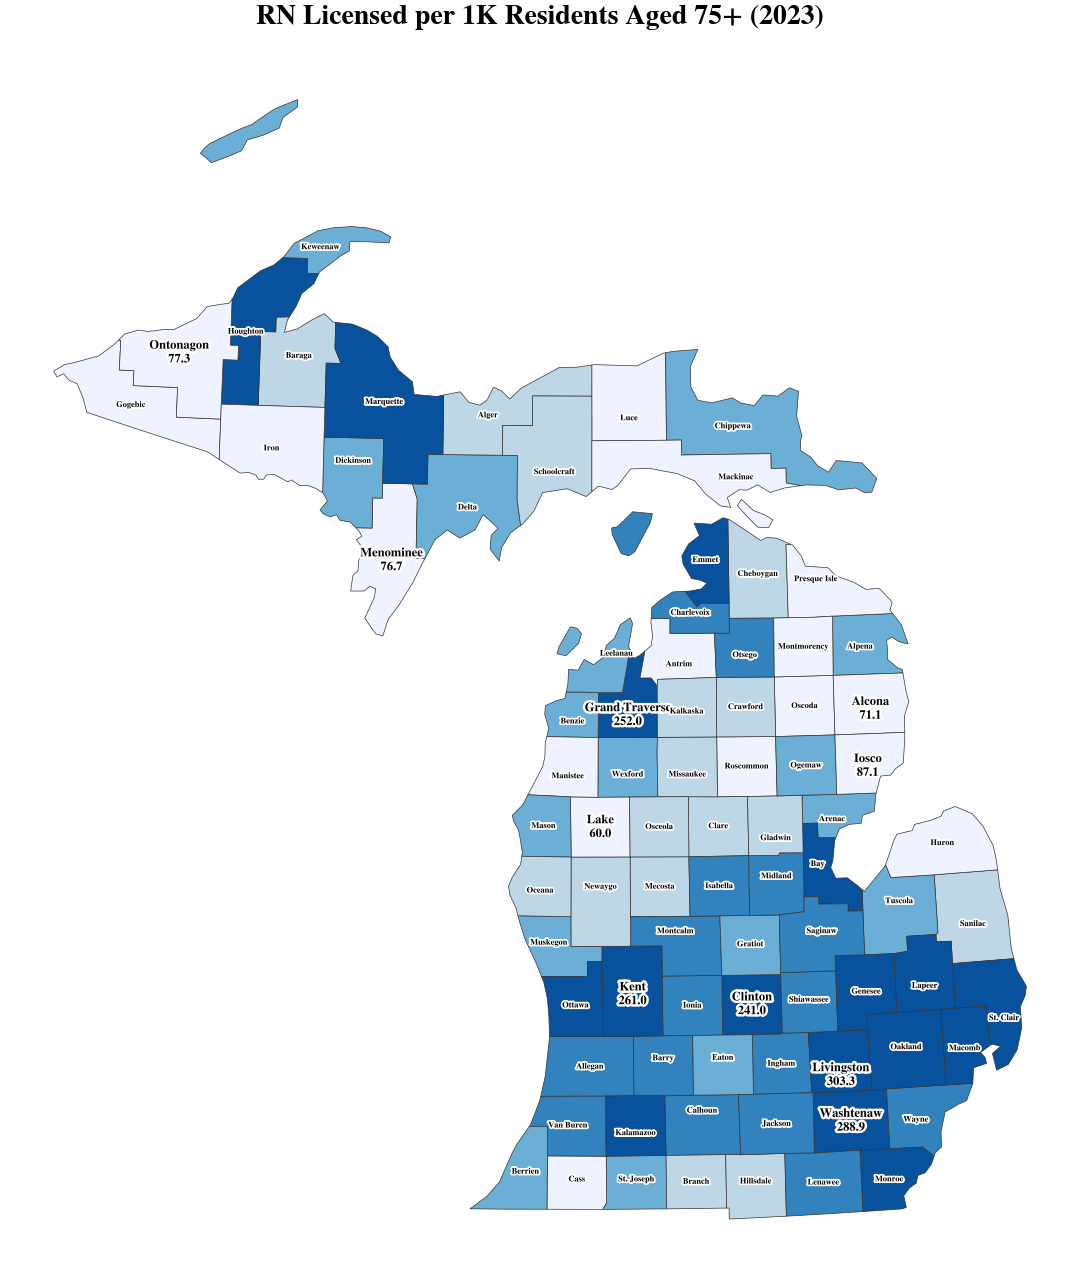

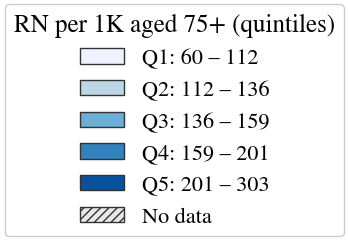

saved ../figures/legend_rn_per_1k_75plus_2023.png


In [14]:
make_heatmap(snap, mi, 'rn_per_1k_75plus',
             title=f'RN Licensed per 1K Residents Aged 75+ ({snap_year})',
             palette=PALETTE,
             legend_title='RN per 1K aged 75+ (quintiles)',
             fmt='{:.1f}',
             source='MI Nurse Licensure (BPL) / ACS pop 75+',
             show_stars=False, draw_legend=False,
             out_png=FIG_DIR / f'heatmap_rn_per_1k_75plus_{snap_year}.png')
save_legend(snap, mi, 'rn_per_1k_75plus', 'RN per 1K aged 75+ (quintiles)', PALETTE,
            out_png=FIG_DIR / f'legend_rn_per_1k_75plus_{snap_year}.png')

## Heatmap 4b — LPN per 1,000 residents aged 75+ (2023)

LPN companion to Heatmap 4. Because LPNs are the workforce most concentrated in nursing homes, the 75+ denominator is the closest of all the scalings to the structurally relevant need measure for this occupation.

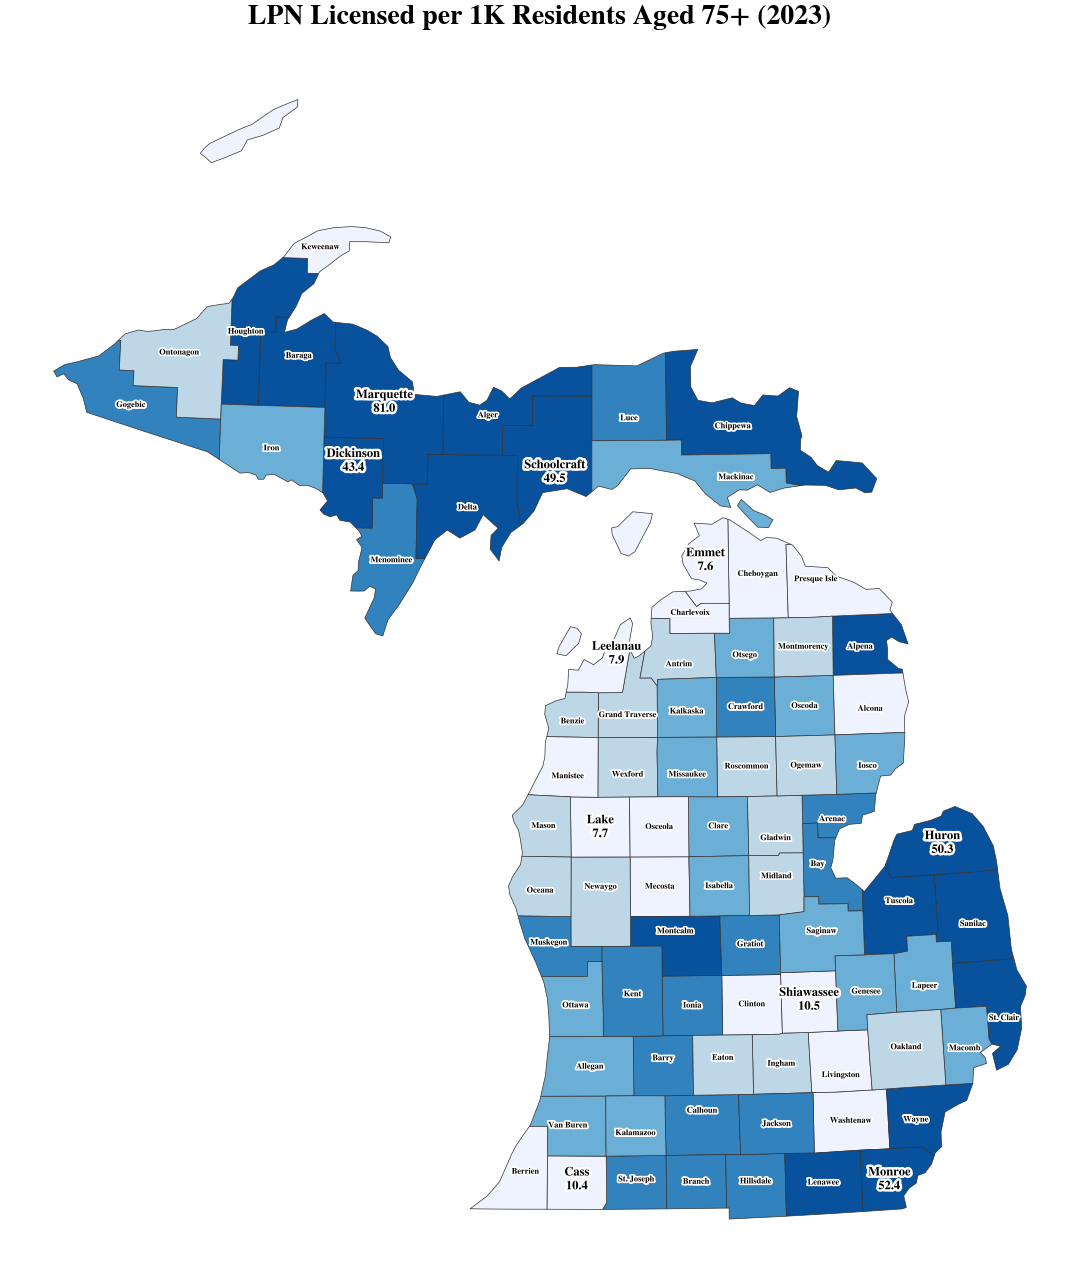

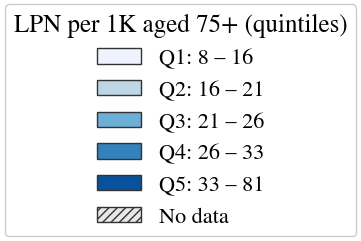

saved ../figures/legend_lpn_per_1k_75plus_2023.png


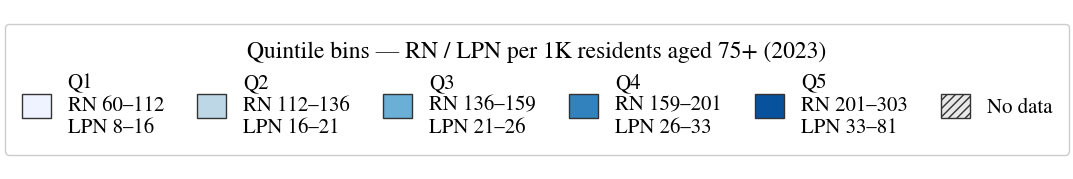

saved ../figures/legend_combined_per_1k_75plus_2023.png


In [15]:
make_heatmap(snap, mi, 'lpn_per_1k_75plus',
             title=f'LPN Licensed per 1K Residents Aged 75+ ({snap_year})',
             palette=PALETTE,
             legend_title='LPN per 1K aged 75+ (quintiles)',
             fmt='{:.1f}',
             source='MI Nurse Licensure (BPL) / ACS pop 75+',
             show_stars=False, draw_legend=False,
             out_png=FIG_DIR / f'heatmap_lpn_per_1k_75plus_{snap_year}.png')
save_legend(snap, mi, 'lpn_per_1k_75plus', 'LPN per 1K aged 75+ (quintiles)', PALETTE,
            out_png=FIG_DIR / f'legend_lpn_per_1k_75plus_{snap_year}.png')
save_combined_legend(snap, mi, 'rn_per_1k_75plus', 'lpn_per_1k_75plus', PALETTE,
                     out_png=FIG_DIR / f'legend_combined_per_1k_75plus_{snap_year}.png',
                     unit_label='RN / LPN per 1K residents aged 75+ (2023)')

## Heatmap 5b — Percent of population aged 75+ (2023)

The oldest-old need share itself — the denominator behind Heatmaps 3b & 4b, mapped directly. Read alongside them: a county dark here and light there carries high oldest-old need with thin nurse supply per 75+ resident.

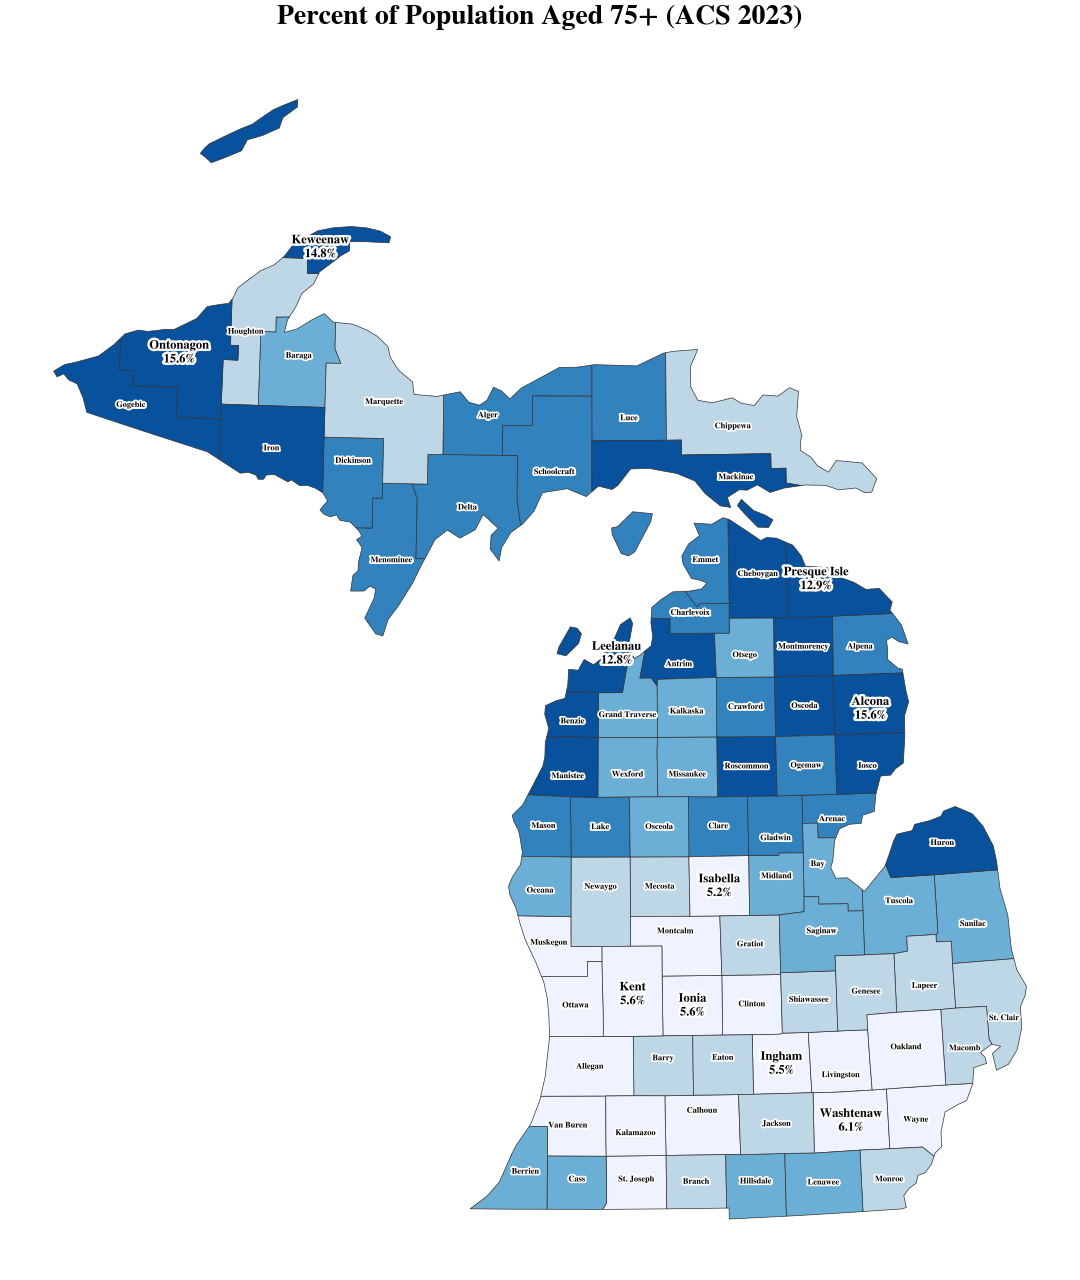

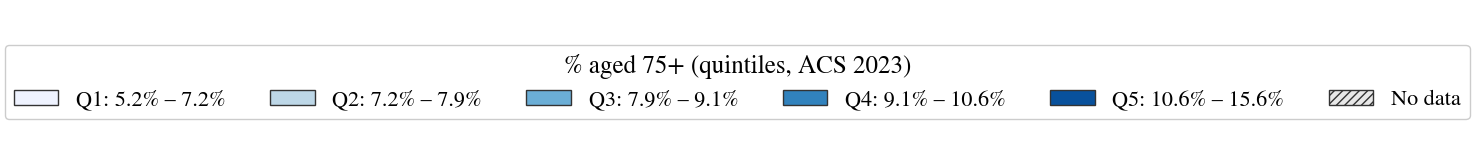

saved ../figures/legend_pct_75plus_2023.png


In [16]:
make_heatmap(snap, mi, 'pct_75plus_used',
             title=f'Percent of Population Aged 75+ (ACS {snap_year})',
             palette=PALETTE,
             legend_title=f'% aged 75+ (quintiles, ACS {snap_year})',
             fmt='{:.1f}%',
             source='U.S. Census Bureau ACS 5-Year, Table B01001',
             show_stars=False, draw_legend=False, edge_fmt='{:.1f}%',
             out_png=FIG_DIR / f'heatmap_pct_75plus_{snap_year}.png')
save_legend(snap, mi, 'pct_75plus_used',
            f'% aged 75+ (quintiles, ACS {snap_year})', PALETTE,
            out_png=FIG_DIR / f'legend_pct_75plus_{snap_year}.png',
            edge_fmt='{:.1f}%', ncol=6, figsize=(13, 2))

---
# Side-by-side RN | LPN composites

Two-panel figures (RN left, LPN right) sharing one horizontal quintile legend below, each map quintiled independently. Produced for (a) the per-100K maps and (b) the per-1K aged-75+ geriatric maps. Saved to `../figures/`.

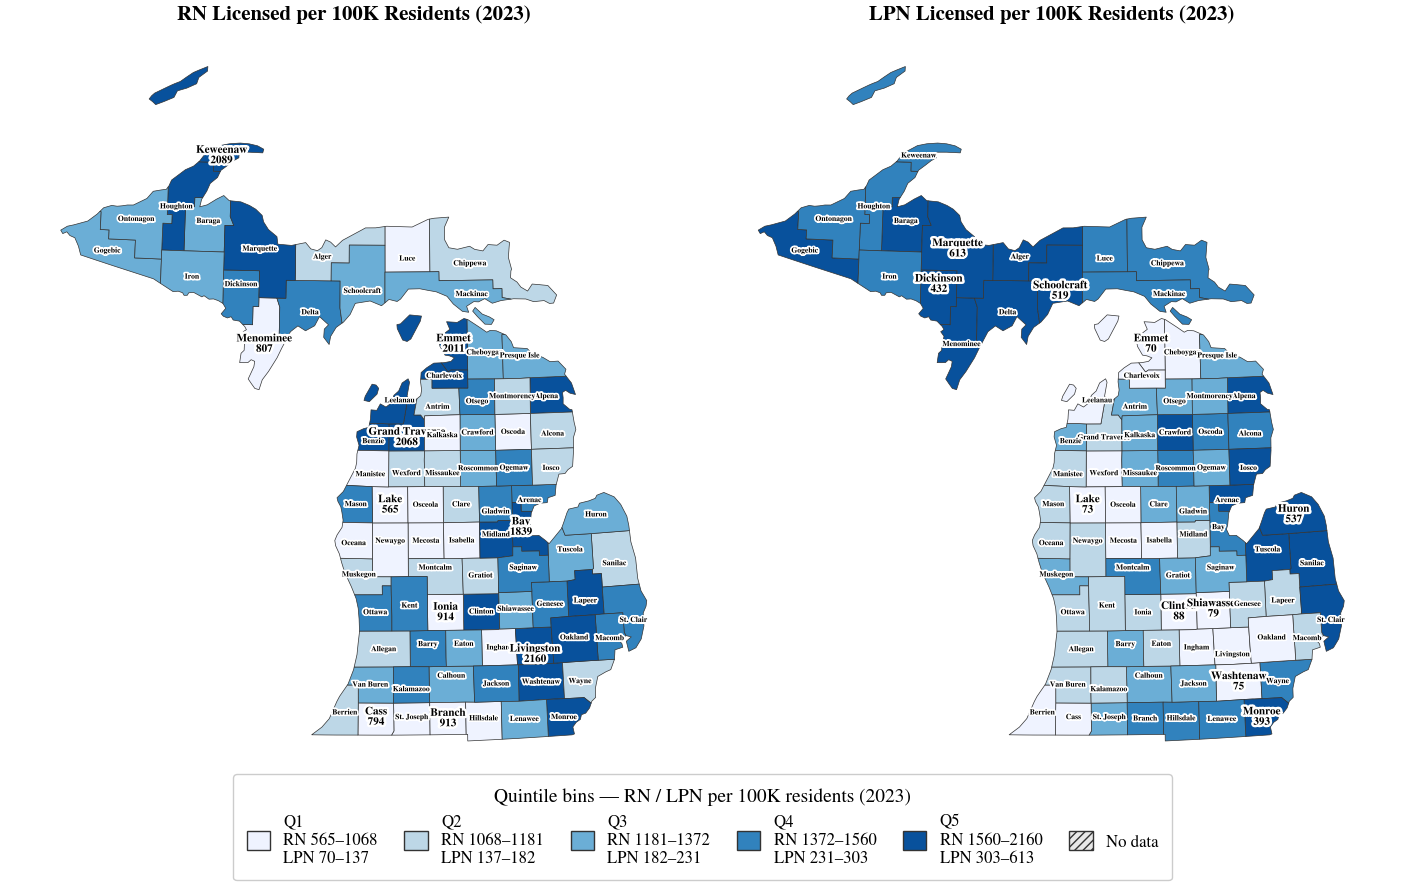

saved ../figures/heatmap_rn_lpn_per_100k_2023.png


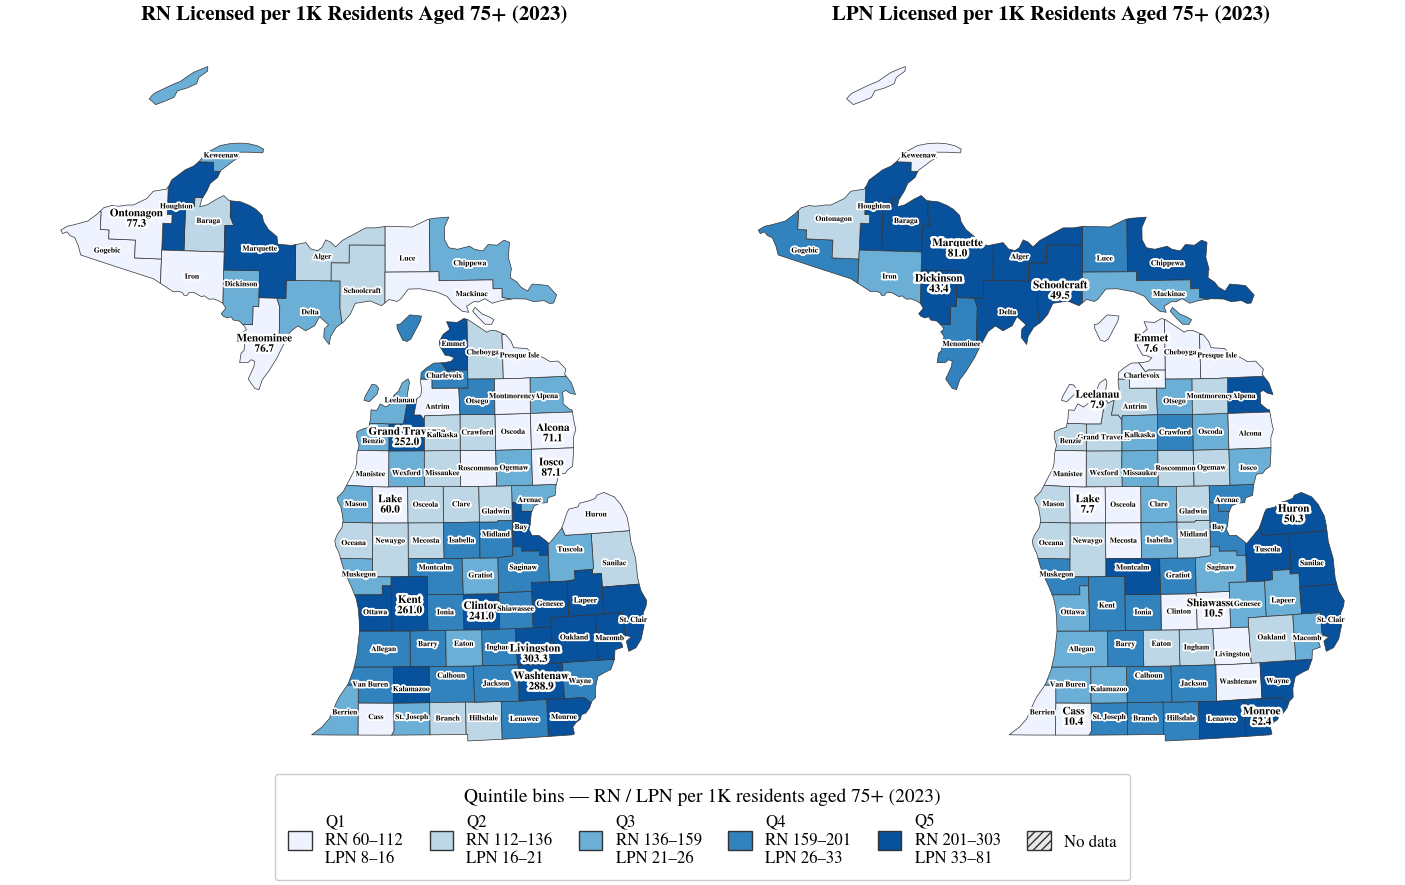

saved ../figures/heatmap_rn_lpn_per_1k_65plus_2023.png


In [17]:
# ── Side-by-side RN | LPN composite with a shared horizontal quintile legend ──
def _draw_choropleth(ax, snap_df, mi_geom, var, title, palette, fmt='{:.0f}', show_stars=False):
    gdf = mi_geom.merge(snap_df[['fips', 'county_name', var]], on='fips', how='left').copy()
    valid = gdf[var].notna()
    gdf.loc[valid, 'qbin'], q_edges = pd.qcut(gdf.loc[valid, var], q=5, labels=False,
                                              retbins=True, duplicates='drop')
    gdf.plot(column='qbin', cmap=ListedColormap(palette), linewidth=0.5, edgecolor='#333333',
             categorical=True, legend=False,
             missing_kwds={'color': '#e8e8e8', 'edgecolor': '#333333', 'hatch': '////'}, ax=ax)
    name_style = dict(ha='center', va='center', fontsize=5.5, color='#000000', fontweight='bold',
                      path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
    hl_style = dict(ha='center', va='center', fontsize=8.0, color='#000000', fontweight='bold',
                    path_effects=[pe.withStroke(linewidth=3.5, foreground='white')])
    ranked = gdf.dropna(subset=[var]).sort_values(var)
    significant = set(pd.concat([ranked.head(5), ranked.tail(5)])['fips'])
    for _, row in gdf.iterrows():
        if pd.isna(row.geometry): continue
        pt = row.geometry.representative_point()
        name = row['county_name'] if isinstance(row['county_name'], str) else row['NAME']
        is_msa = row['fips'] in msa_central_fips
        offset = (0, 12) if (is_msa and show_stars) else (0, 0)
        if row['fips'] in significant and pd.notna(row[var]):
            ax.annotate(f"{name}\n{fmt.format(row[var])}", xy=(pt.x, pt.y), xytext=offset,
                        textcoords='offset points', **hl_style)
        else:
            ax.annotate(name, xy=(pt.x, pt.y), xytext=offset, textcoords='offset points', **name_style)
        if is_msa and show_stars:
            ax.scatter([pt.x], [pt.y], marker='*', s=160, color='#c62828',
                       edgecolor='black', linewidth=0.6, zorder=6)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=10)
    ax.set_axis_off()
    return np.round(q_edges, 0)


def make_side_by_side(snap_df, mi_geom, rn_var, lpn_var, rn_title, lpn_title,
                      palette, unit_label, out_png, fmt='{:.0f}'):
    fig = plt.figure(figsize=(18, 11))
    gs = fig.add_gridspec(2, 2, height_ratios=[12, 1.7], hspace=0.0, wspace=0.0)
    ax_rn = fig.add_subplot(gs[0, 0]); ax_lpn = fig.add_subplot(gs[0, 1])
    ax_leg = fig.add_subplot(gs[1, :]); ax_leg.set_axis_off()
    rn_e = _draw_choropleth(ax_rn, snap_df, mi_geom, rn_var, rn_title, palette, fmt)
    lpn_e = _draw_choropleth(ax_lpn, snap_df, mi_geom, lpn_var, lpn_title, palette, fmt)
    patches = [Patch(facecolor=palette[i], edgecolor='#333333',
                     label=(f'Q{i+1}\nRN {rn_e[i]:.0f}\u2013{rn_e[i+1]:.0f}\n'
                            f'LPN {lpn_e[i]:.0f}\u2013{lpn_e[i+1]:.0f}'))
               for i in range(len(palette))]
    patches.append(Patch(facecolor='#e8e8e8', edgecolor='#333333', hatch='////', label='No data'))
    ax_leg.legend(handles=patches, title=f'Quintile bins \u2014 {unit_label}', loc='center',
                  ncol=len(patches), frameon=True, fontsize=12, title_fontsize=14,
                  handlelength=1.4, handleheight=1.4, columnspacing=1.6, borderpad=0.8)
    plt.savefig(out_png, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print('saved', out_png)


# (a) per-100K RN | LPN
make_side_by_side(snap, mi, 'rn_per_100k', 'lpn_per_100k',
                  f'RN Licensed per 100K Residents ({snap_year})',
                  f'LPN Licensed per 100K Residents ({snap_year})',
                  PALETTE, f'RN / LPN per 100K residents ({snap_year})',
                  out_png=FIG_DIR / f'heatmap_rn_lpn_per_100k_{snap_year}.png', fmt='{:.0f}')

# (b) geriatric: RN | LPN per 1K aged 75+ (75+ content under 65plus filename per project convention)
make_side_by_side(snap, mi, 'rn_per_1k_75plus', 'lpn_per_1k_75plus',
                  f'RN Licensed per 1K Residents Aged 75+ ({snap_year})',
                  f'LPN Licensed per 1K Residents Aged 75+ ({snap_year})',
                  PALETTE, f'RN / LPN per 1K residents aged 75+ ({snap_year})',
                  out_png=FIG_DIR / f'heatmap_rn_lpn_per_1k_65plus_{snap_year}.png', fmt='{:.1f}')